# Matplotlib — Hard

## Rules
- Object-oriented Matplotlib only.
- Prefer explicit choices over defaults.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
rng = np.random.default_rng(SEED)

## Exercise 1 — Data-anchored vs layout-anchored text

### Task
Reproduce the figure above.

### Constraints
- Place one text label at a fixed location in the data space.
- Place one text label that stays in the same corner of the plot area even if the axis limits change.
- Use explicit axis limits and labels.

In [3]:
x = np.linspace(0, 10, 500)
y = np.sin(x) + 0.22 * rng.normal(size=len(x))

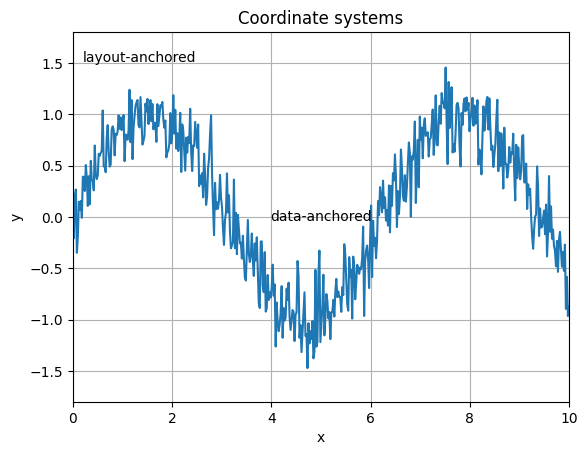

In [4]:
fig, ax = plt.subplots()

ax.plot(x, y, linewidth=1.5)
ax.set_xlim(0, 10)
ax.set_ylim(-1.8, 1.8)

ax.text(5.0, 0.0, "data-anchored", ha="center", va="center", fontsize=10)
ax.text(0.02, 0.95, "layout-anchored", transform=ax.transAxes, ha="left", va="top", fontsize=10)

ax.set_title("Coordinate systems")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True)

plt.show()

## Exercise 2 — Canvas-level label

### Task
Reproduce the figure above.

### Constraints
- Add a label that is tied to the overall canvas and does not move with the plot area.
- Keep explicit axis limits and labels.
- The canvas-level label must remain visible when resizing the figure.

In [5]:
x = np.linspace(0, 10, 500)
y2 = np.cos(x) + 0.18 * rng.normal(size=len(x))

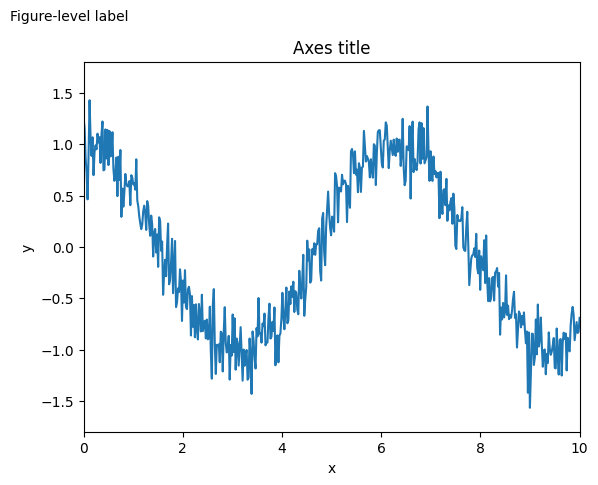

In [6]:
fig, ax = plt.subplots()

ax.plot(x, y2, linewidth=1.5)
ax.set_xlim(0, 10)
ax.set_ylim(-1.8, 1.8)

ax.set_title("Axes title")
ax.set_xlabel("x")
ax.set_ylabel("y")

fig.text(0.01, 0.99, "Figure-level label", ha="left", va="top", fontsize=10)

plt.show()

## Exercise 3 — Image-based rendering with a fixed color scale

### Task
Reproduce the figure above.

### Constraints
- Render the matrix as an image.
- The color mapping must use a fixed numeric range so the colors are comparable across reruns.
- Attach a color scale to the correct visual element.
- Choose orientation so the displayed matrix matches the data layout.

In [7]:
A = rng.normal(size=(25, 40))

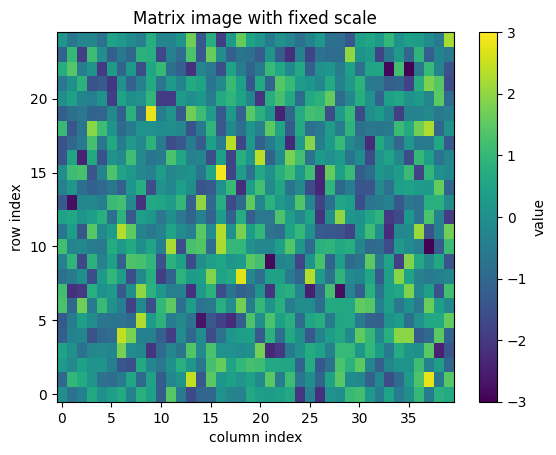

In [27]:
fig, ax = plt.subplots()

im = ax.imshow(A, vmin=-3, vmax=3, origin="lower", aspect="auto")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("value")

ax.set_title("Matrix image with fixed scale")
ax.set_xlabel("column index")
ax.set_ylabel("row index")

plt.show()

## Exercise 4 — Correlation heatmap (partial matrix)

### Task
Reproduce the figure above.

### Constraints
- Compute pairwise relationships between the feature columns.
- Show only the lower triangle (excluding the diagonal).
- Keep a fixed color scale spanning the full theoretical range.
- Add a color scale and readable axis tick labels.

In [9]:
n = 220
f1 = rng.normal(size=n)
f2 = 0.7 * f1 + 0.3 * rng.normal(size=n)
f3 = -0.5 * f1 + 0.5 * rng.normal(size=n)
f4 = rng.normal(size=n)
X = np.column_stack([f1, f2, f3, f4])  # shape (n, 4)
feature_names = ["f1", "f2", "f3", "f4"]


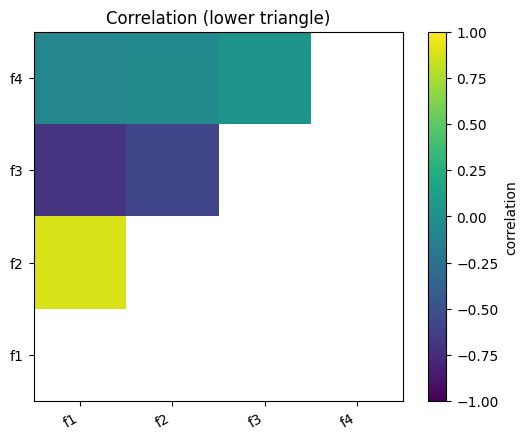

In [10]:
corr = np.corrcoef(X, rowvar=False)

fig, ax = plt.subplots()

mask = np.tril(np.ones_like(corr, dtype=bool), k=-1)
corr_lower = np.where(mask, corr, np.nan)

im = ax.imshow(corr_lower, vmin=-1, vmax=1, origin="lower")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("correlation")

ax.set_xticks(range(len(feature_names)))
ax.set_yticks(range(len(feature_names)))
ax.set_xticklabels(feature_names, rotation=30, ha="right")
ax.set_yticklabels(feature_names)

ax.set_title("Correlation (lower triangle)")

plt.show()

## Exercise 5 — Contour lines with labeled levels

### Task
Reproduce the figure above.

### Constraints
- Draw contour lines for a 2D surface.
- Use an explicit set of numeric levels (not automatic).
- Add labels on the contour lines.
- Use explicit axis limits and labels.

In [11]:
gx = np.linspace(-2.5, 2.5, 220)
gy = np.linspace(-2.0, 2.0, 180)
GX, GY = np.meshgrid(gx, gy)
GZ = np.exp(-(GX**2 + (1.4*GY)**2)) - 0.6 * np.exp(-((GX-1.2)**2 + (GY+0.6)**2))

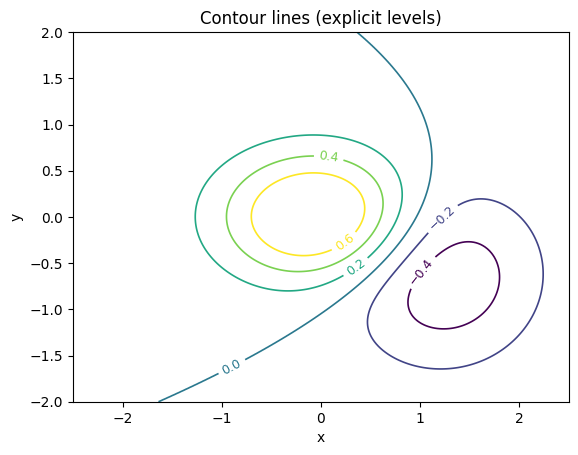

In [12]:
fig, ax = plt.subplots()

levels = [-0.4, -0.2, 0.0, 0.2, 0.4, 0.6]
cs = ax.contour(GX, GY, GZ, levels=levels, linewidths=1.2)
ax.clabel(cs, inline=True, fontsize=9)

ax.set_title("Contour lines (explicit levels)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_xlim(gx.min(), gx.max())
ax.set_ylim(gy.min(), gy.max())

plt.show()

## Exercise 6 — Filled contours with a consistent scale

### Task
Reproduce the figure above.

### Constraints
- Show a filled representation of a 2D surface.
- Overlay contour lines on top of the filled field.
- Attach a color scale to the filled field (not the line overlay).
- Use explicit numeric levels and axis limits.

In [13]:
gx = np.linspace(-2.5, 2.5, 220)
gy = np.linspace(-2.0, 2.0, 180)
GX, GY = np.meshgrid(gx, gy)
GZ = np.exp(-(GX**2 + (1.4*GY)**2)) - 0.6 * np.exp(-((GX-1.2)**2 + (GY+0.6)**2))

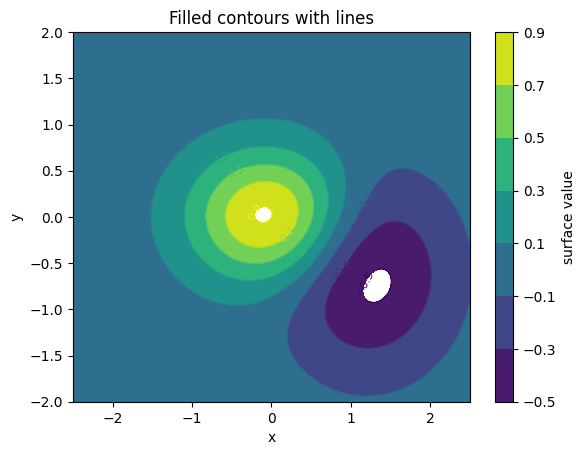

In [30]:
fig, ax = plt.subplots()

levels = np.linspace(-0.5, 0.9, 8)
cf = ax.contourf(GX, GY, GZ, levels=levels)
cs = ax.contour(GX, GY, GZ, levels=levels, linewidths=0.8)
ax.clabel(cs, inline=True, fontsize=8)

cbar = fig.colorbar(cf, ax=ax)
cbar.set_label("surface value")

ax.set_title("Filled contours with lines")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_xlim(gx.min(), gx.max())
ax.set_ylim(gy.min(), gy.max())

plt.show()

## Exercise 7 — Embedded zoomed view

### Task
Reproduce the figure above.

### Constraints
- Create a secondary plot area embedded inside the main plot area.
- The embedded plot must show a zoomed region of the main data.
- Visually link the zoomed region to the embedded plot.
- The embedded plot must remain correctly positioned when resizing the figure.

In [15]:
x = np.linspace(0, 10, 500)
y = np.sin(x) + 0.22 * rng.normal(size=len(x))

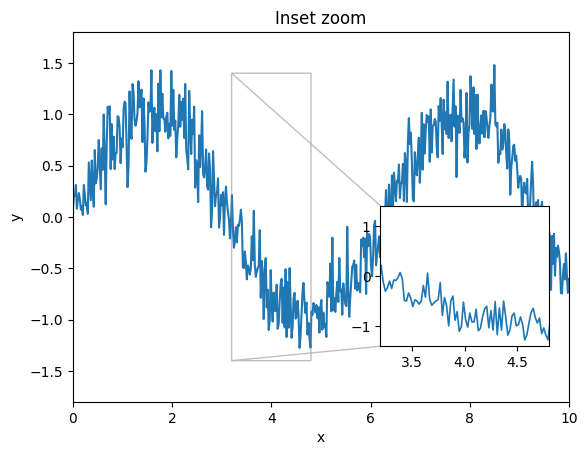

In [16]:
fig, ax = plt.subplots()

zoom_xmin, zoom_xmax = 3.2, 4.8

ax.plot(x, y, linewidth=1.5)
ax.set_xlim(0, 10)
ax.set_ylim(-1.8, 1.8)
ax.set_title("Inset zoom")
ax.set_xlabel("x")
ax.set_ylabel("y")

axins = ax.inset_axes([0.62, 0.15, 0.34, 0.38])
axins.plot(x, y, linewidth=1.2)
axins.set_xlim(zoom_xmin, zoom_xmax)
axins.set_ylim(-1.4, 1.4)
axins.set_xticks([3.5, 4.0, 4.5])
axins.set_yticks([-1.0, 0.0, 1.0])

ax.indicate_inset_zoom(axins)


## Exercise 8 — Multi-panel figure with consistent scaling

### Task
Reproduce the figure above.

### Constraints
- Create multiple vertically stacked plot areas in one figure.
- Ensure the scales match across panels so values are directly comparable.
- Use explicit axis limits and ticks.
- Add a legend to each panel without obscuring the data.

In [ ]:
x = np.linspace(0, 10, 500)
y = np.sin(x) + 0.22 * rng.normal(size=len(x))

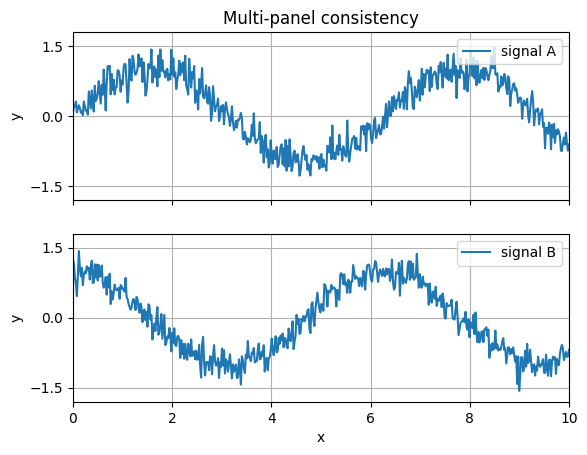

In [31]:
fig, axs = plt.subplots(2, 1, sharex=True, sharey=True)

axs[0].plot(x, y, linewidth=1.5, label="signal A")
axs[1].plot(x, y2, linewidth=1.5, label="signal B")

for ax in axs:
    ax.set_xlim(0, 10)
    ax.set_ylim(-1.8, 1.8)
    ax.set_yticks([-1.5, 0.0, 1.5])
    ax.grid(True)
    ax.legend(loc="upper right")

axs[0].set_title("Multi-panel consistency")
axs[1].set_xlabel("x")
axs[0].set_ylabel("y")
axs[1].set_ylabel("y")

plt.show()

## Exercise 9 — A fixed badge that does not move with the data

### Task
Reproduce the figure above.

### Constraints
- Add a rectangular badge anchored to the plot area corner (not data space).
- The badge and its label must stay in the same corner when rescaling or changing axis limits.
- Keep explicit axis limits and labels.

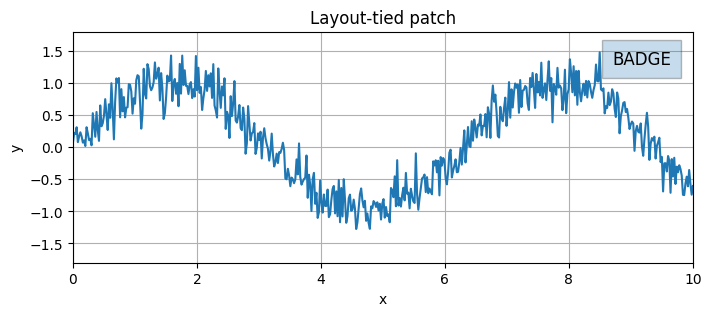

In [33]:
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(x, y, linewidth=1.5)
ax.set_xlim(0, 10)
ax.set_ylim(-1.8, 1.8)

ax.text(
    0.965, 0.88, "BADGE",
    transform=ax.transAxes,
    ha="right", va="center",
    fontsize=12,
    bbox=dict(
        boxstyle="square,pad=0.6",
        alpha=0.25,
        linewidth=1.0
    )
)
ax.set_title("Layout-tied patch")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True)

plt.show()